In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import scanpy as sc
import igraph
import scvelo as scv
import loompy as lmp
import anndata

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Read in the subset of clusters exported from Loupe Browser
Clusters_Loupe = pd.read_csv("/storage/liuxiaodongLab/jiangjing/temp/scvelo_text/WB_Lysis_Granulocytes_3p_Introns_8kCells/download/3p-Neutrophils-clusters.csv", delimiter=',',index_col=0)


In [4]:
# Create list with only Neutrophil Barcodes
# This will be used later to subset the count matrix
Neutrophils_BCs = Clusters_Loupe.index

In [5]:
Neutrophils_BCs

Index(['AAACCCAGTTGTGCAT-1', 'AAACGAACAATTGCGT-1', 'AAACGCTTCGAGTCCG-1',
       'AAAGAACAGCGACTAG-1', 'AAAGAACAGTCGAGGT-1', 'AAAGAACCACTGCACG-1',
       'AAAGAACCAGTGCGCT-1', 'AAAGAACTCAGCTCTC-1', 'AAAGGATAGGAGCTGT-1',
       'AAAGGATCACCCAAGC-1',
       ...
       'TTTGGAGTCGCGTTTC-1', 'TTTGGAGTCGTTCTAT-1', 'TTTGGTTAGTAGTCCT-1',
       'TTTGGTTCAATAGTAG-1', 'TTTGGTTTCGAACGCC-1', 'TTTGTTGAGTAAGCAT-1',
       'TTTGTTGCAACCAACT-1', 'TTTGTTGTCGAGTACT-1', 'TTTGTTGTCGCTACAA-1',
       'TTTGTTGTCTTCGCTG-1'],
      dtype='object', name='Barcode', length=3343)

In [6]:
# Read UMAP exported from Loupe Browser 
UMAP_Loupe = pd.read_csv("/storage/liuxiaodongLab/jiangjing/temp/scvelo_text/WB_Lysis_Granulocytes_3p_Introns_8kCells/download/3p-Neutrophils-UMAP-Projection.csv", delimiter=',',index_col=0)

In [11]:
UMAP_Loupe

,X Coordinate,Y Coordinate
Barcode,,
AAACCCAGTTGTGCAT-1,-0.001582,2.180147
AAACGAACAATTGCGT-1,5.135044,-4.409836
AAACGCTTCGAGTCCG-1,6.190524,-2.858611
AAAGAACAGCGACTAG-1,-2.429371,3.459695
AAAGAACAGTCGAGGT-1,5.388083,-5.391562
...,...,...
TTTGTTGAGTAAGCAT-1,6.827351,-0.854632
TTTGTTGCAACCAACT-1,3.792248,-3.236916
TTTGTTGTCGAGTACT-1,7.078238,-3.863012


In [12]:
# Tansform to Numpy (for formatting)
UMAP_Loupe = UMAP_Loupe.to_numpy()

In [13]:
UMAP_Loupe

array([[-1.58232408e-03,  2.18014739e+00],
       [ 5.13504428e+00, -4.40983558e+00],
       [ 6.19052403e+00, -2.85861105e+00],
       ...,
       [ 7.07823770e+00, -3.86301154e+00],
       [ 5.38129839e+00, -5.10858282e+00],
       [ 6.74767682e+00, -1.13205385e+00]])

In [14]:
# Define Path to cellranger output
Path10x='/storage/liuxiaodongLab/jiangjing/temp/scvelo_text/WB_Lysis_Granulocytes_3p_Introns_8kCells/outs/filtered_feature_bc_matrix'

# Read filtered feature bc matrix output from cellranger count
Neutro3p = sc.read_10x_mtx(Path10x,var_names='gene_symbols',cache=True)
Neutro3p

AnnData object with n_obs × n_vars = 8000 × 38606
    var: 'gene_ids', 'feature_types'

In [15]:
# These are the barcodes (n_obs) = 8000
# This is the number set in --force-cells
Neutro3p.obs
# These are the gene_ids (n_vars) = 36,601
Neutro3p.var_names
Neutro3p_df = Neutro3p.to_df()
Neutro3p_df.head()

,DDX11L2,MIR1302-2HG,FAM138A,ENSG00000290826,OR4F5,ENSG00000238009,ENSG00000239945,ENSG00000239906,ENSG00000241860,ENSG00000241599,...,ENSG00000275249,ENSG00000274792,ENSG00000274175,ENSG00000275869,ENSG00000273554,ENSG00000277836,ENSG00000278633,ENSG00000276017,ENSG00000278817,ENSG00000277196
AAACCCAAGGCACTCC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCACAACTCCCT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAGTACGAGCA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAGTTGTGCAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCATCTTCGGAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
# Filter Cells to only Neutrophils
Neutro3p = Neutro3p[Neutrophils_BCs]

In [25]:
# Add Clusters from Loupe to object
Neutro3p.obs['Loupe'] = Clusters_Loupe

# Add UMAP from Loupe to object
Neutro3p.obsm["X_umap"] = UMAP_Loupe

In [27]:
print(scv.__version__)

0.3.3


In [31]:
# Read velocyto output
VelNeutro3p = sc.read('/storage/liuxiaodongLab/jiangjing/temp/scvelo_text/WB_Lysis_Granulocytes_3p_Introns_8kCells/velocyto/WB_Lysis_Granulocytes_3p_Introns_8kCells.loom', cache=True)

In [37]:
VelNeutro3p

AnnData object with n_obs × n_vars = 8000 × 38606
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [36]:
# Merge velocyto and cellranger outputs
Neutro3p = scv.utils.merge(Neutro3p, VelNeutro3p)

Neutro3p

AnnData object with n_obs × n_vars = 3343 × 38606
    obs: 'Loupe', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size'
    var: 'gene_ids', 'feature_types', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    obsm: 'X_umap'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [38]:
##min_shared_counts:Minimum number of cells required to be expressed
scv.pp.filter_and_normalize(Neutro3p, min_shared_counts=30, n_top_genes=2000)

Filtered out 37475 genes that are detected 30 counts (shared).
Normalized count data: X, spliced, unspliced.
Skip filtering by dispersion since number of variables are less than `n_top_genes`.
Logarithmized X.


/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


In [39]:
Neutro3p

AnnData object with n_obs × n_vars = 3343 × 1131
    obs: 'Loupe', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'gene_ids', 'feature_types', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'log1p'
    obsm: 'X_umap'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [40]:
#Computes moments for velocity estimation
scv.pp.moments(Neutro3p, n_pcs=30, n_neighbors=30)

/tmp/ipykernel_345387/3411351639.py:1: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(Neutro3p, n_pcs=30, n_neighbors=30)
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute PCA with Scanpy first.
  _set_pca(adata=adata, n_pcs=n_pcs, use_highly_variable=use_highly_variable)


computing neighbors
    finished (0:00:16) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [41]:
Neutro3p

AnnData object with n_obs × n_vars = 3343 × 1131
    obs: 'Loupe', 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'gene_ids', 'feature_types', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'log1p', 'pca', 'neighbors'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

In [42]:
#Recovers the full splicing kinetics of specified genes:基于基因表达的时间动态模型，估计 RNA 剪接动力学的参数（如转录速率、降解速率），为 mode='dynamical' 提供基础
scv.tl.recover_dynamics(Neutro3p)

recovering dynamics (using 1/64 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:29) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)


In [43]:
#使用动态模型（基于基因的动力学参数）计算 RNA 速度，相比默认的 stochastic 模式更精确但计算量更大
scv.tl.velocity(Neutro3p, mode='dynamical')

computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [44]:
#将 RNA 速度信息转换为细胞间的转移概率图（速度图），用于后续轨迹推断和可视化
scv.tl.velocity_graph(Neutro3p)

computing velocity graph (using 1/64 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [45]:
#估计细胞的“潜在时间”，反映细胞在分化或动态过程中的伪时间位置（从起始到终末状态的排序）
scv.tl.recover_latent_time(Neutro3p)

computing terminal states
    identified 3 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)


In [ ]:
# Standard scvelo processing to run Dynamical Mode
scv.pp.filter_and_normalize(Neutro3p, min_shared_counts=30, n_top_genes=2000)
scv.pp.moments(Neutro3p, n_pcs=30, n_neighbors=30)

scv.tl.recover_dynamics(Neutro3p)
scv.tl.velocity(Neutro3p, mode='dynamical')
scv.tl.velocity_graph(Neutro3p)
scv.tl.recover_latent_time(Neutro3p)

Neutro3p

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/

saving figure to file ./figures/scvelo_scVelo-umap-cluster.png


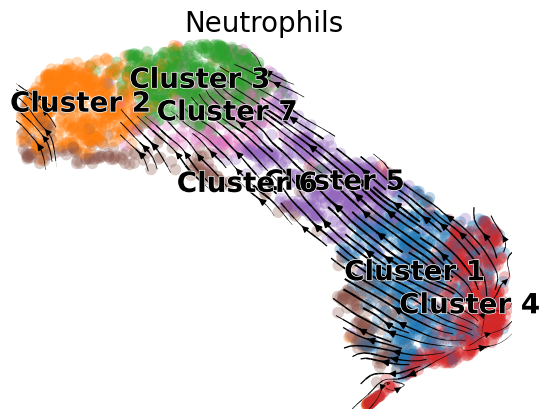

In [46]:
#Stream plot of velocities on the embedding
scv.pl.velocity_embedding_stream(
    Neutro3p, 
    basis="umap",          # 基于 UMAP 降维结果绘制
    color="Loupe",         # 按聚类标签（Loupe 分组）着色
    title='Neutrophils',   # 标题
    fontsize=20,           # 轴标签字体大小
    legend_fontsize=20,    # 图例字体大小
    min_mass=2,            # 忽略低密度区域的流线（避免噪声）
    save='scVelo-umap-cluster.png'  # 保存图像
)

/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/

saving figure to file ./figures/scvelo_scVelo-umap-latent_time.png


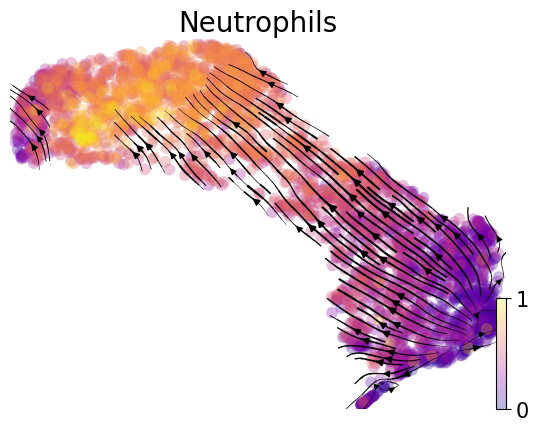

In [47]:
#latent_time 是细胞在 动态过程（如分化、激活、周期等） 中推断出的 伪时间值，表示细胞在该过程中的相对位置（从起始到终末状态）
scv.pl.velocity_embedding_stream(
    Neutro3p,basis="umap",
    color="latent_time",
    title='Neutrophils',
    fontsize=20,legend_fontsize=20,min_mass=2,
    color_map="plasma",
    save='scVelo-umap-latent_time.png')

/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


saving figure to file ./figures/scvelo_heatmap_scVelo-heatmap-latent_time.png


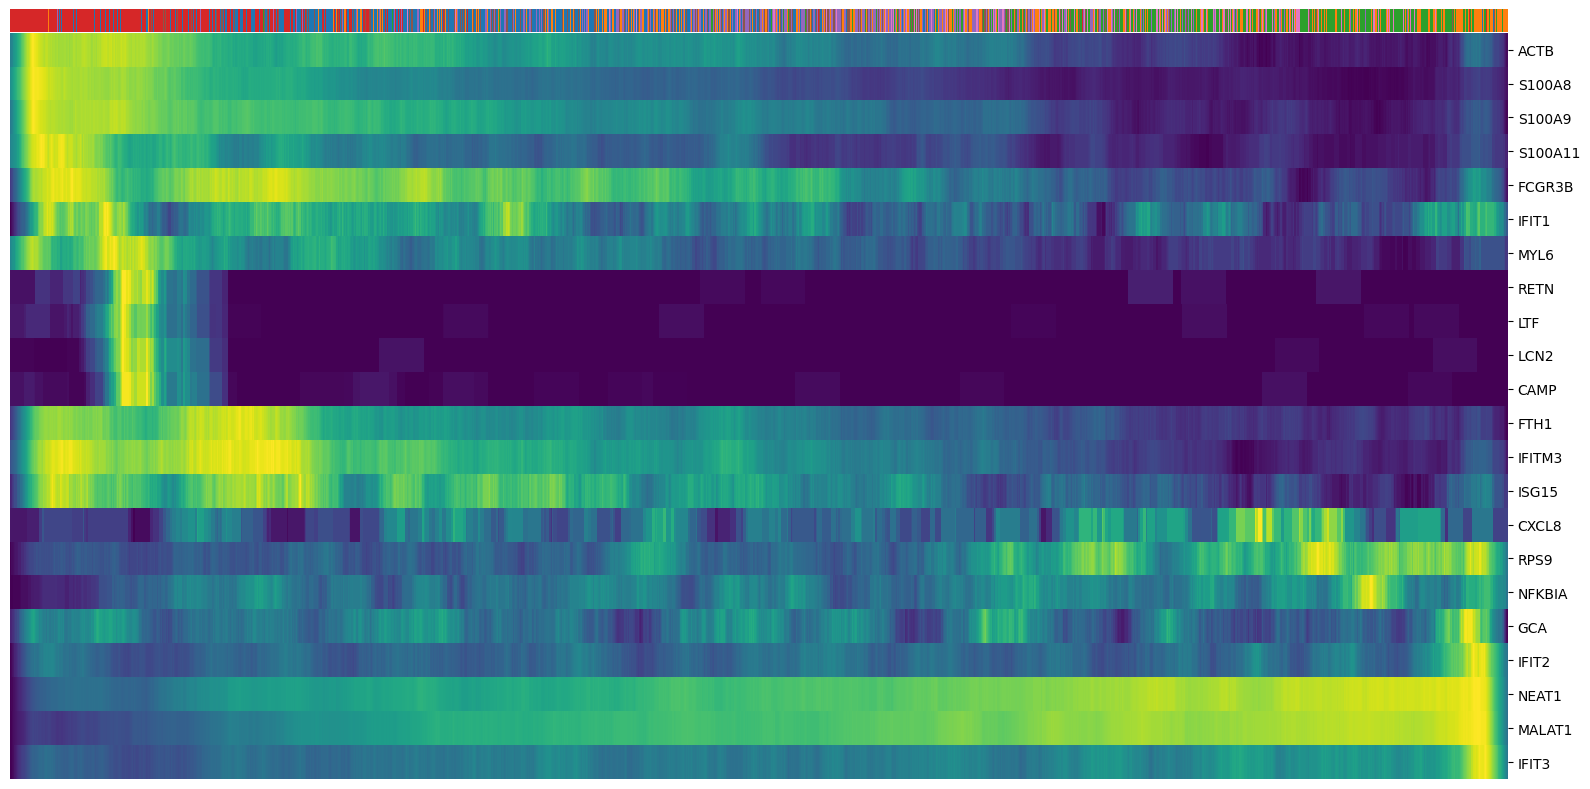

In [48]:
Genes=["RETN","LTF","CAMP","ACTB","GCA","LCN2",
         "S100A8","MYL6","S100A9","FCGR3B","S100A11","FTH1","IFIT1",
         "IFITM3","IFIT3","ISG15","IFIT2","RPS9","NEAT1","MALAT1","NFKBIA","CXCL8"]
scv.pl.heatmap(
    Neutro3p, 
    var_names=Genes,       # 指定要展示的基因列表
    sortby='latent_time',  # 按潜在时间排序细胞
    col_color='Loupe',     # 顶部颜色条：按聚类着色
    n_convolve=100,        # 对时间轴做 100 步滑动平均平滑
    figsize=(16,8),        # 图像尺寸（宽 x 高）
    yticklabels=True,      # 显示基因名称（y轴标签）
    sort=True,             # 对基因按表达模式排序
    colorbar=True,         # 显示颜色条
    show=True,             
    layer="count",         # 使用原始计数数据（非标准化值）
    save='scVelo-heatmap-latent_time.png'
)

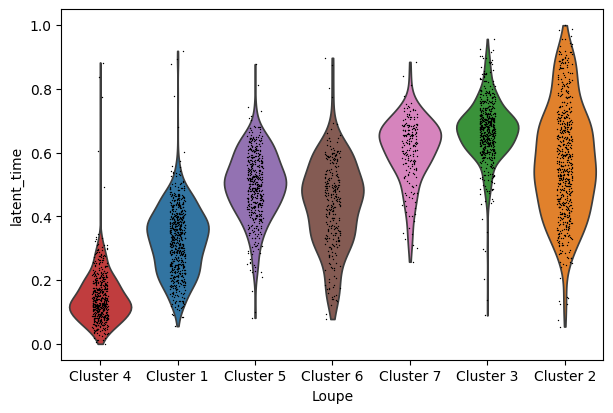

In [49]:
sc.pl.violin(Neutro3p, keys='latent_time',groupby="Loupe",order=["Cluster 4","Cluster 1","Cluster 5","Cluster 6","Cluster 7","Cluster 3","Cluster 2"], save='scVelo-violin-latent_time.png')

In [50]:
# Customize parameters for plots (Size, Color, etc)
# let's set these to improve our plots  
scv.set_figure_params(style="scvelo")  # 使用 scvelo 的默认绘图风格
pl.rcParams["figure.figsize"] = (10,10)  # 全局设置图像大小为 10x10 英寸
Colorss=["#E41A1C","#377EB8","#4DAF4A","#984EA3","#FF7F00","#FFFF33","#A65628","#F781BF"] # 自定义颜色列表（按聚类顺序）

/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/

saving figure to file ./figures/scvelo_scVelo-umap-cluster.png


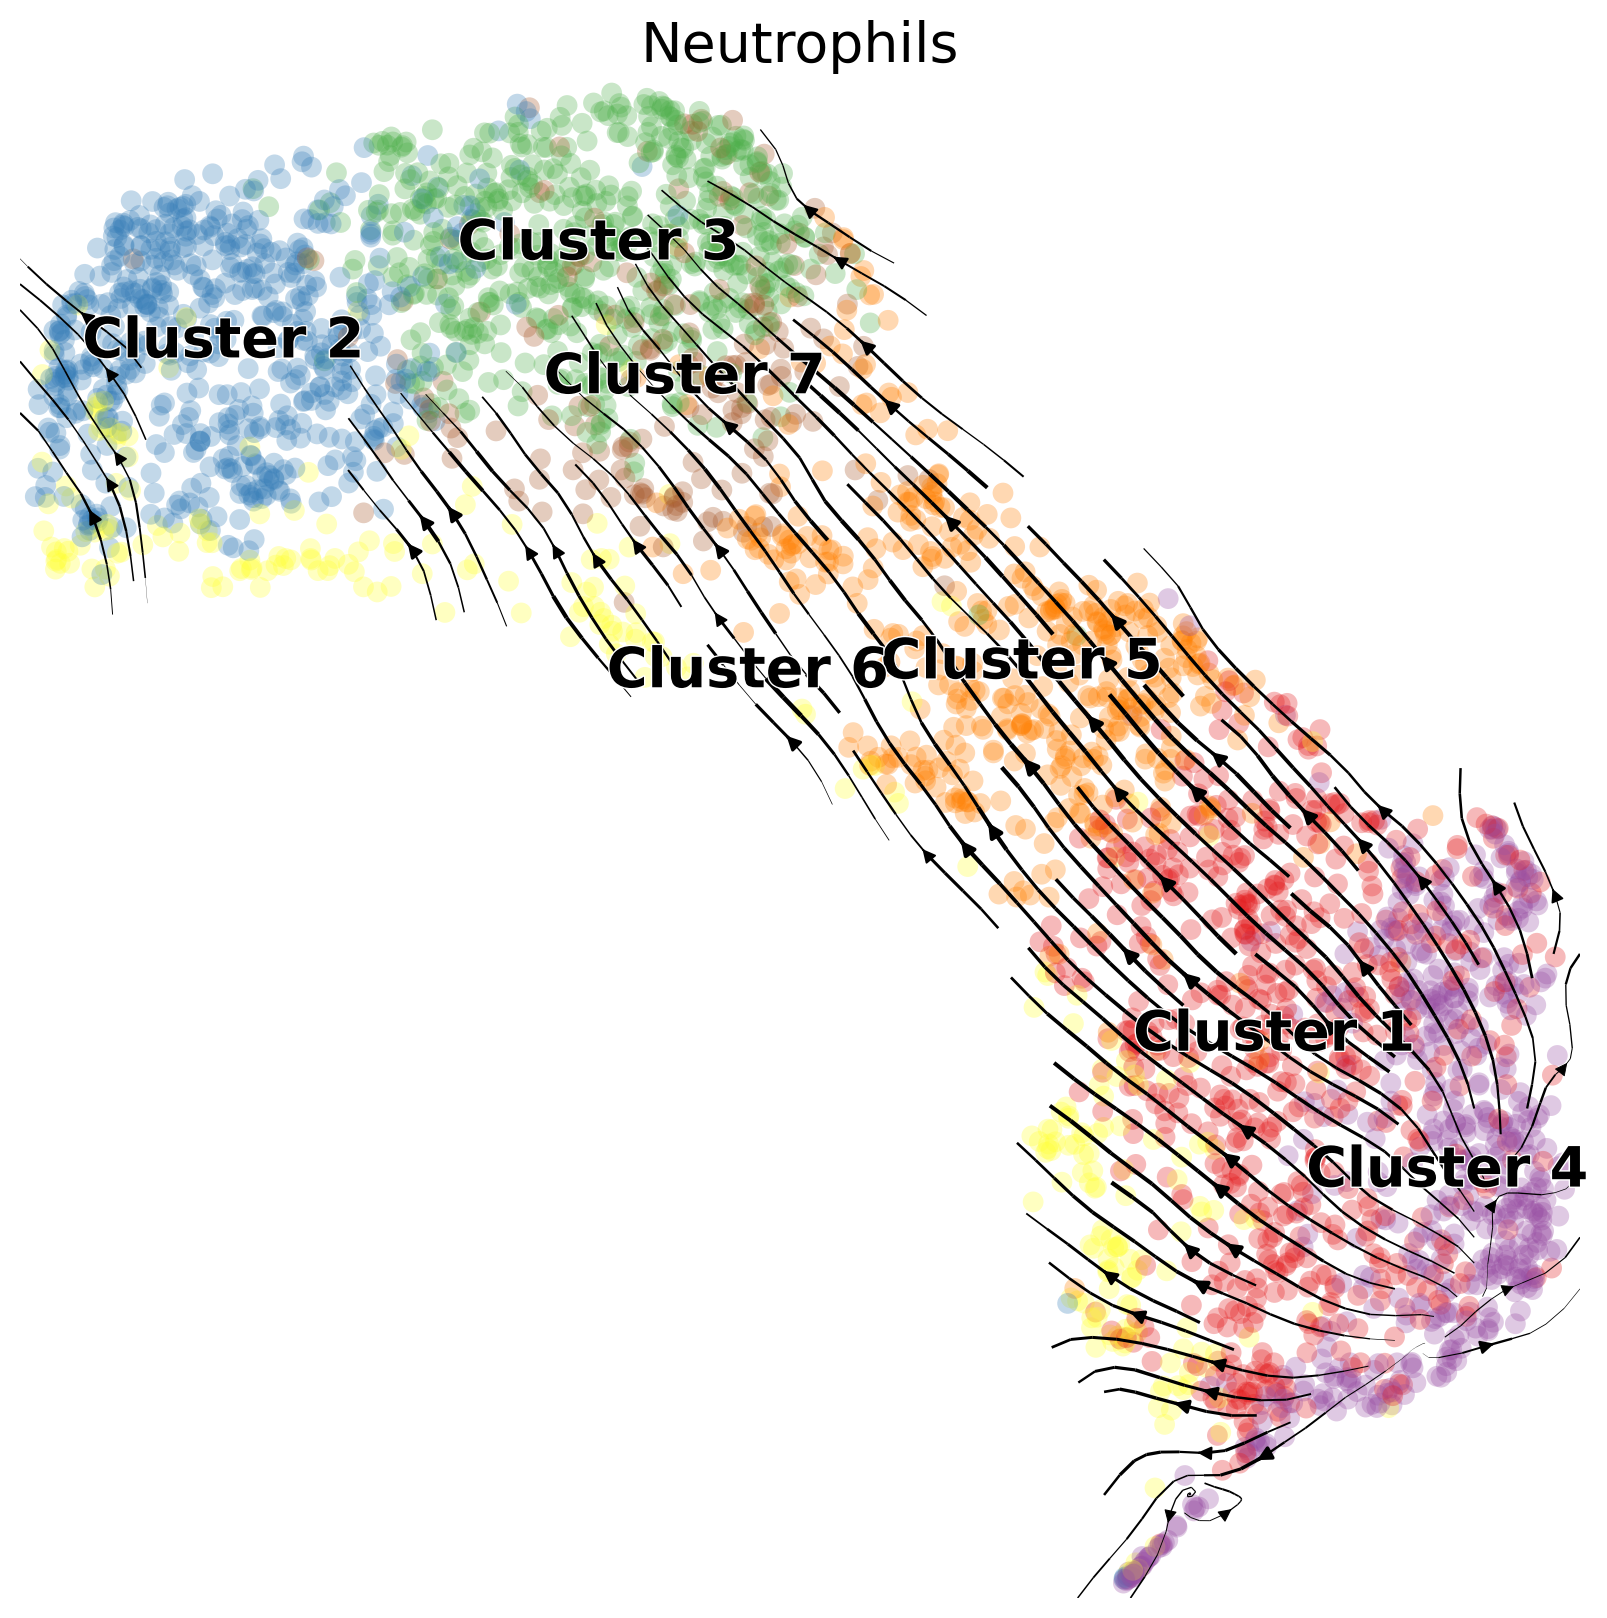

In [55]:
scv.pl.velocity_embedding_stream(
    Neutro3p,
    basis="umap",
    color="Loupe",
    title='Neutrophils',
    fontsize=20,legend_fontsize=20,min_mass=2,palette=Colorss,
    save='scVelo-umap-cluster.png')

/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/

saving figure to file ./figures/scvelo_scVelo-umap-latent_time.png


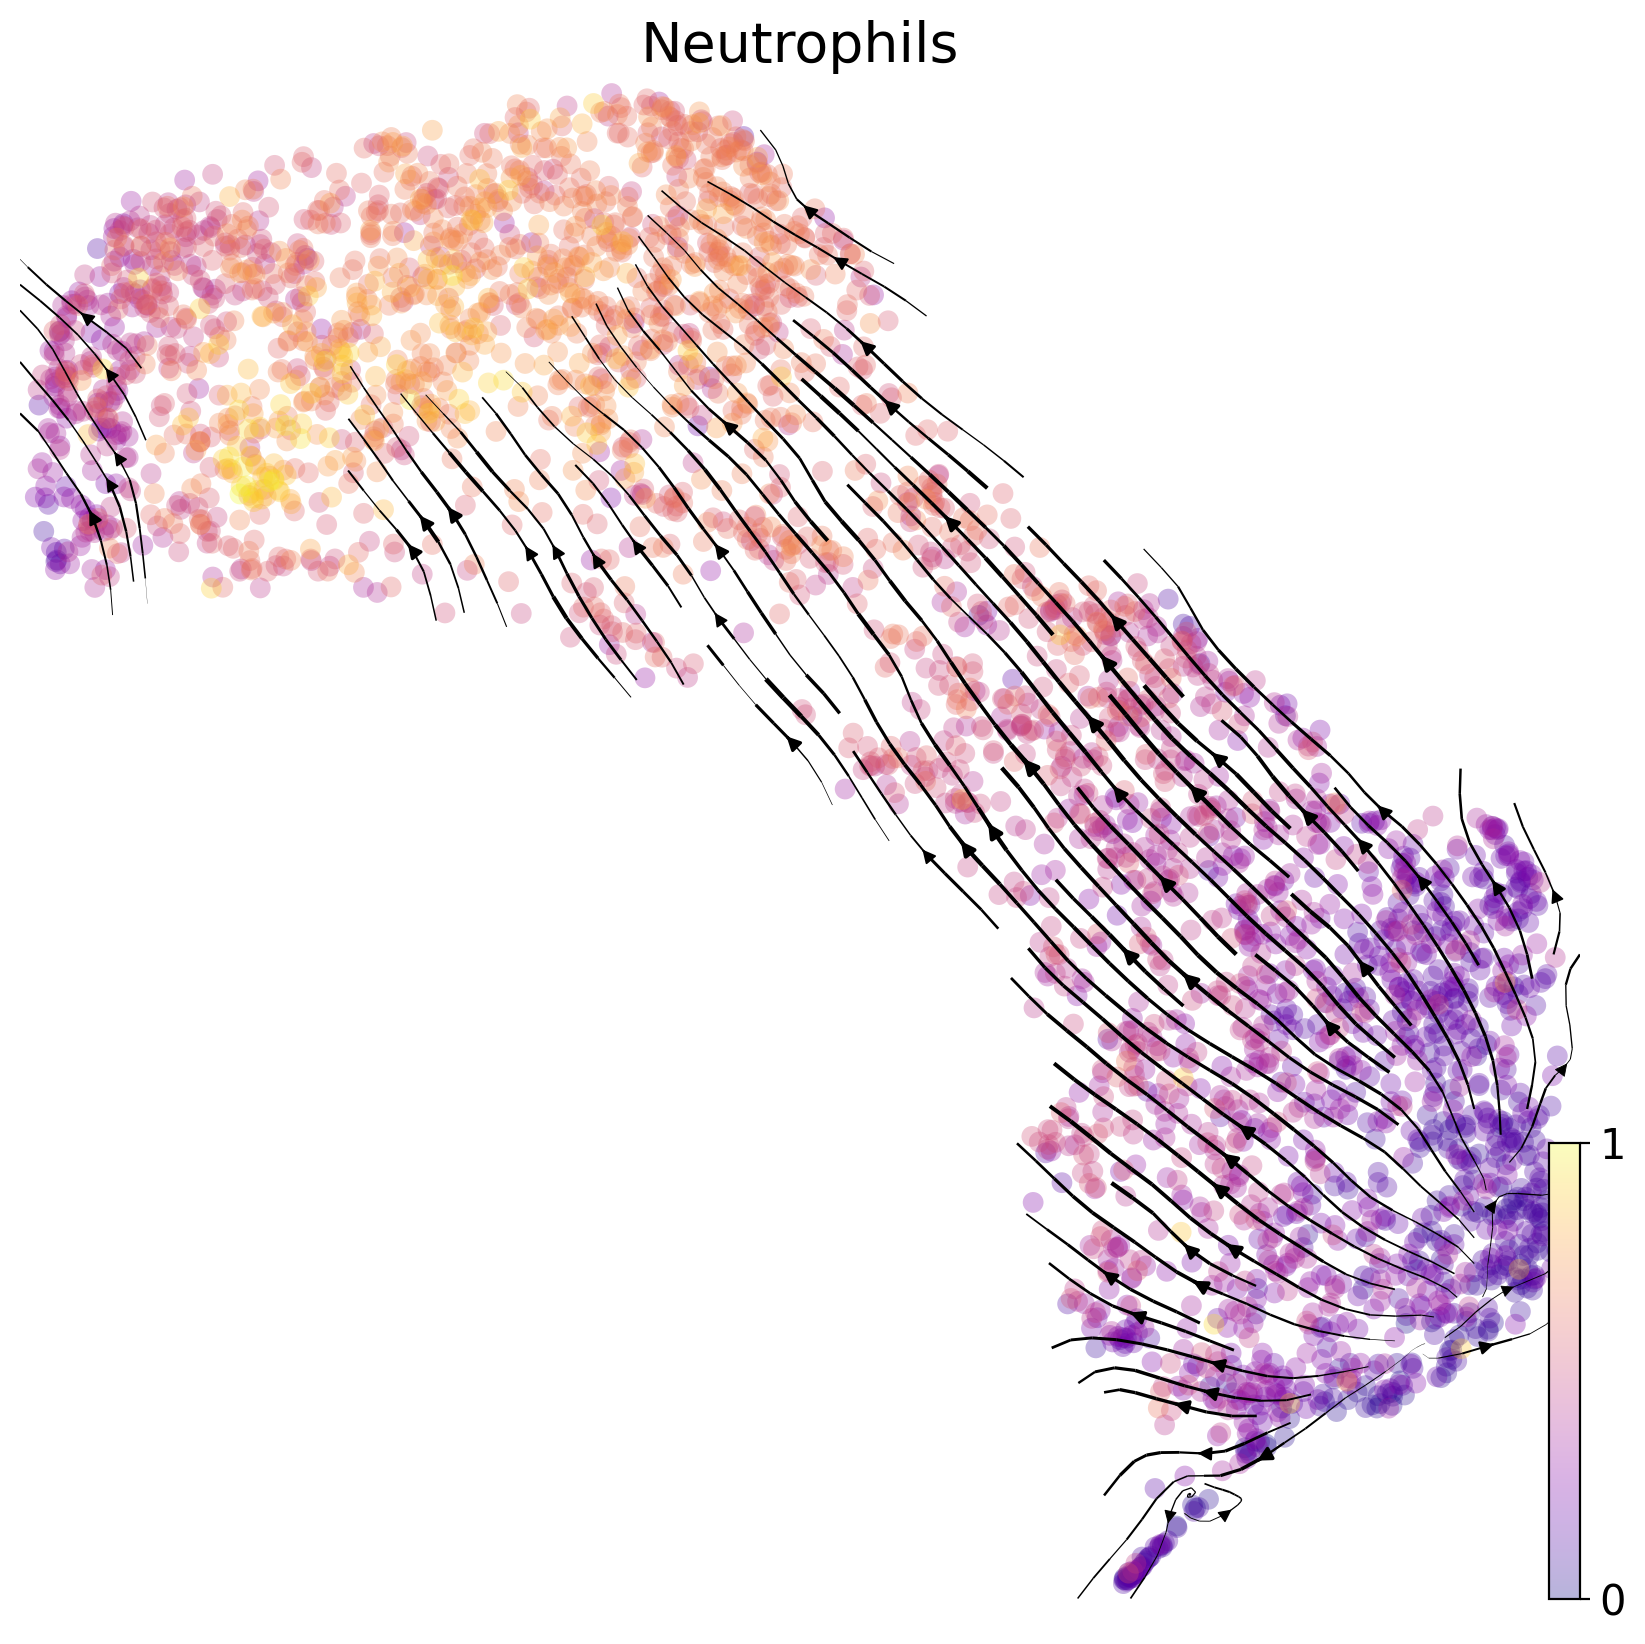

In [52]:
scv.pl.velocity_embedding_stream(
    Neutro3p,
    basis="umap",
    color="latent_time",
    title='Neutrophils',
    fontsize=20,legend_fontsize=20,min_mass=2,
    color_map="plasma",
    save='scVelo-umap-latent_time.png')

/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


saving figure to file ./figures/scvelo_heatmap_scVelo-heatmap-latent_time.png


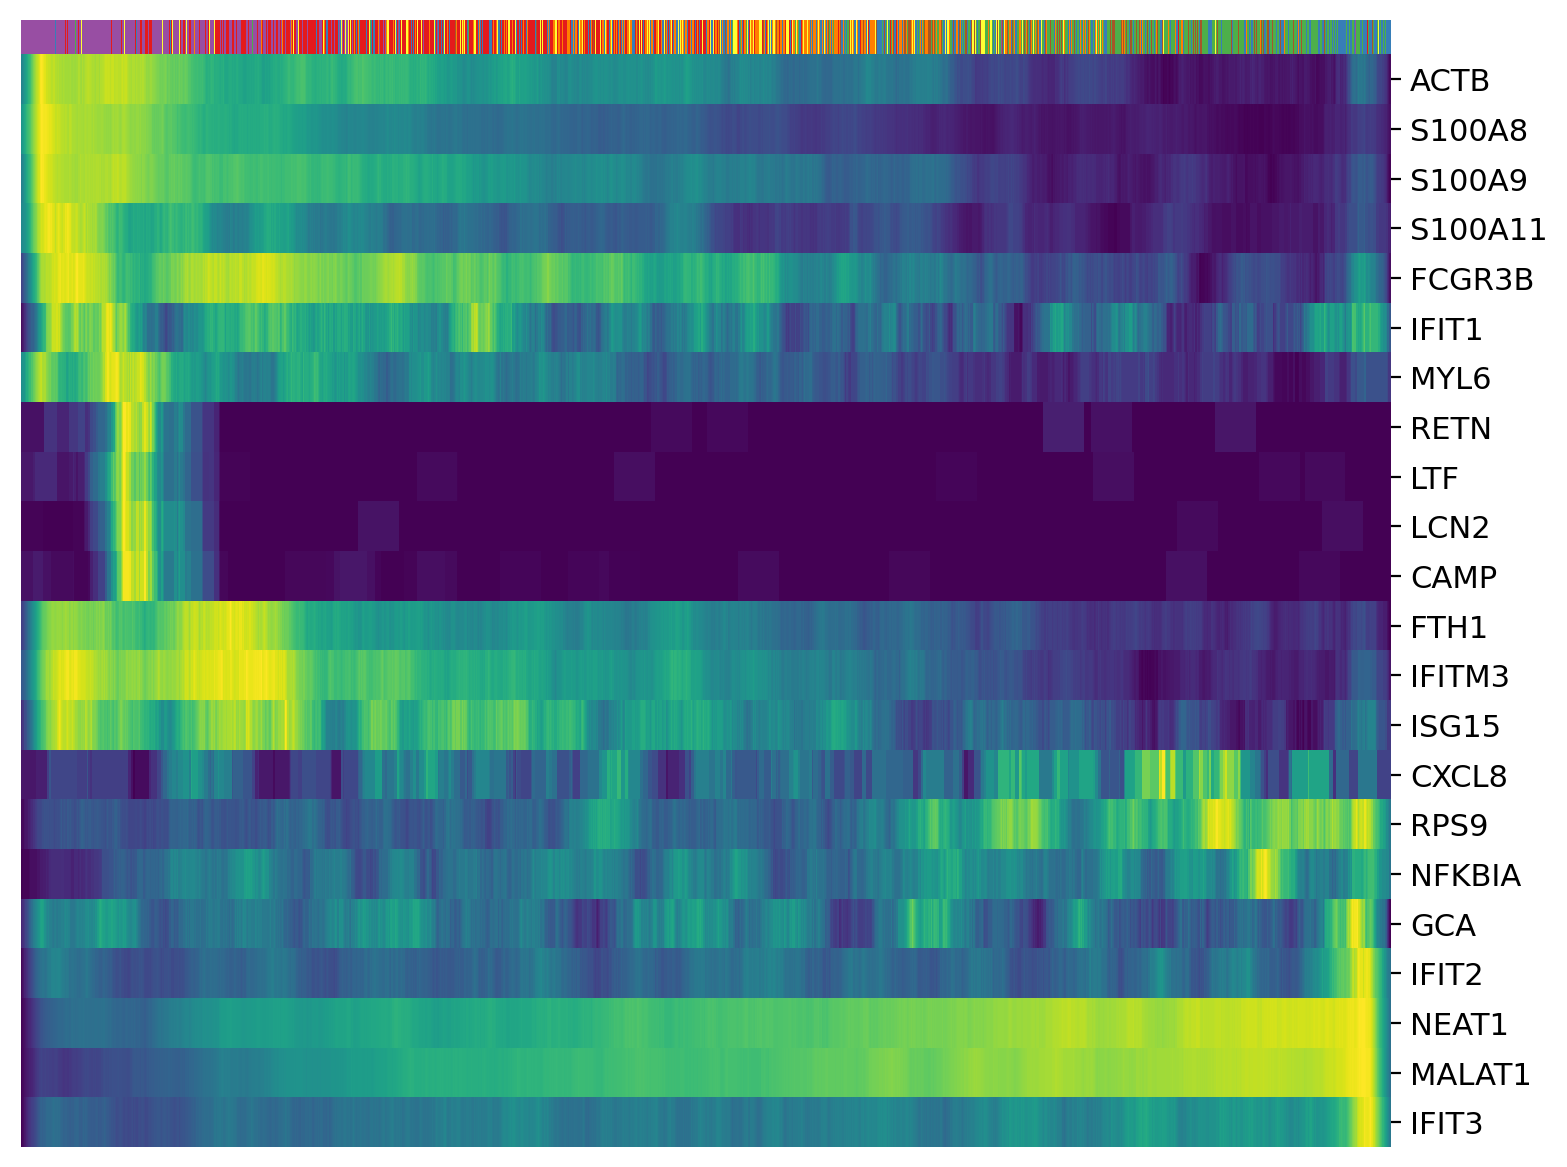

In [53]:
scv.pl.heatmap(
    Neutro3p, 
    var_names=Genes, 
    sortby='latent_time', 
    col_color='Loupe', 
    n_convolve=100,figsize=(8,6),yticklabels=True,sort=True,colorbar=True,show=True,
    layer="count", 
    save='scVelo-heatmap-latent_time.png')

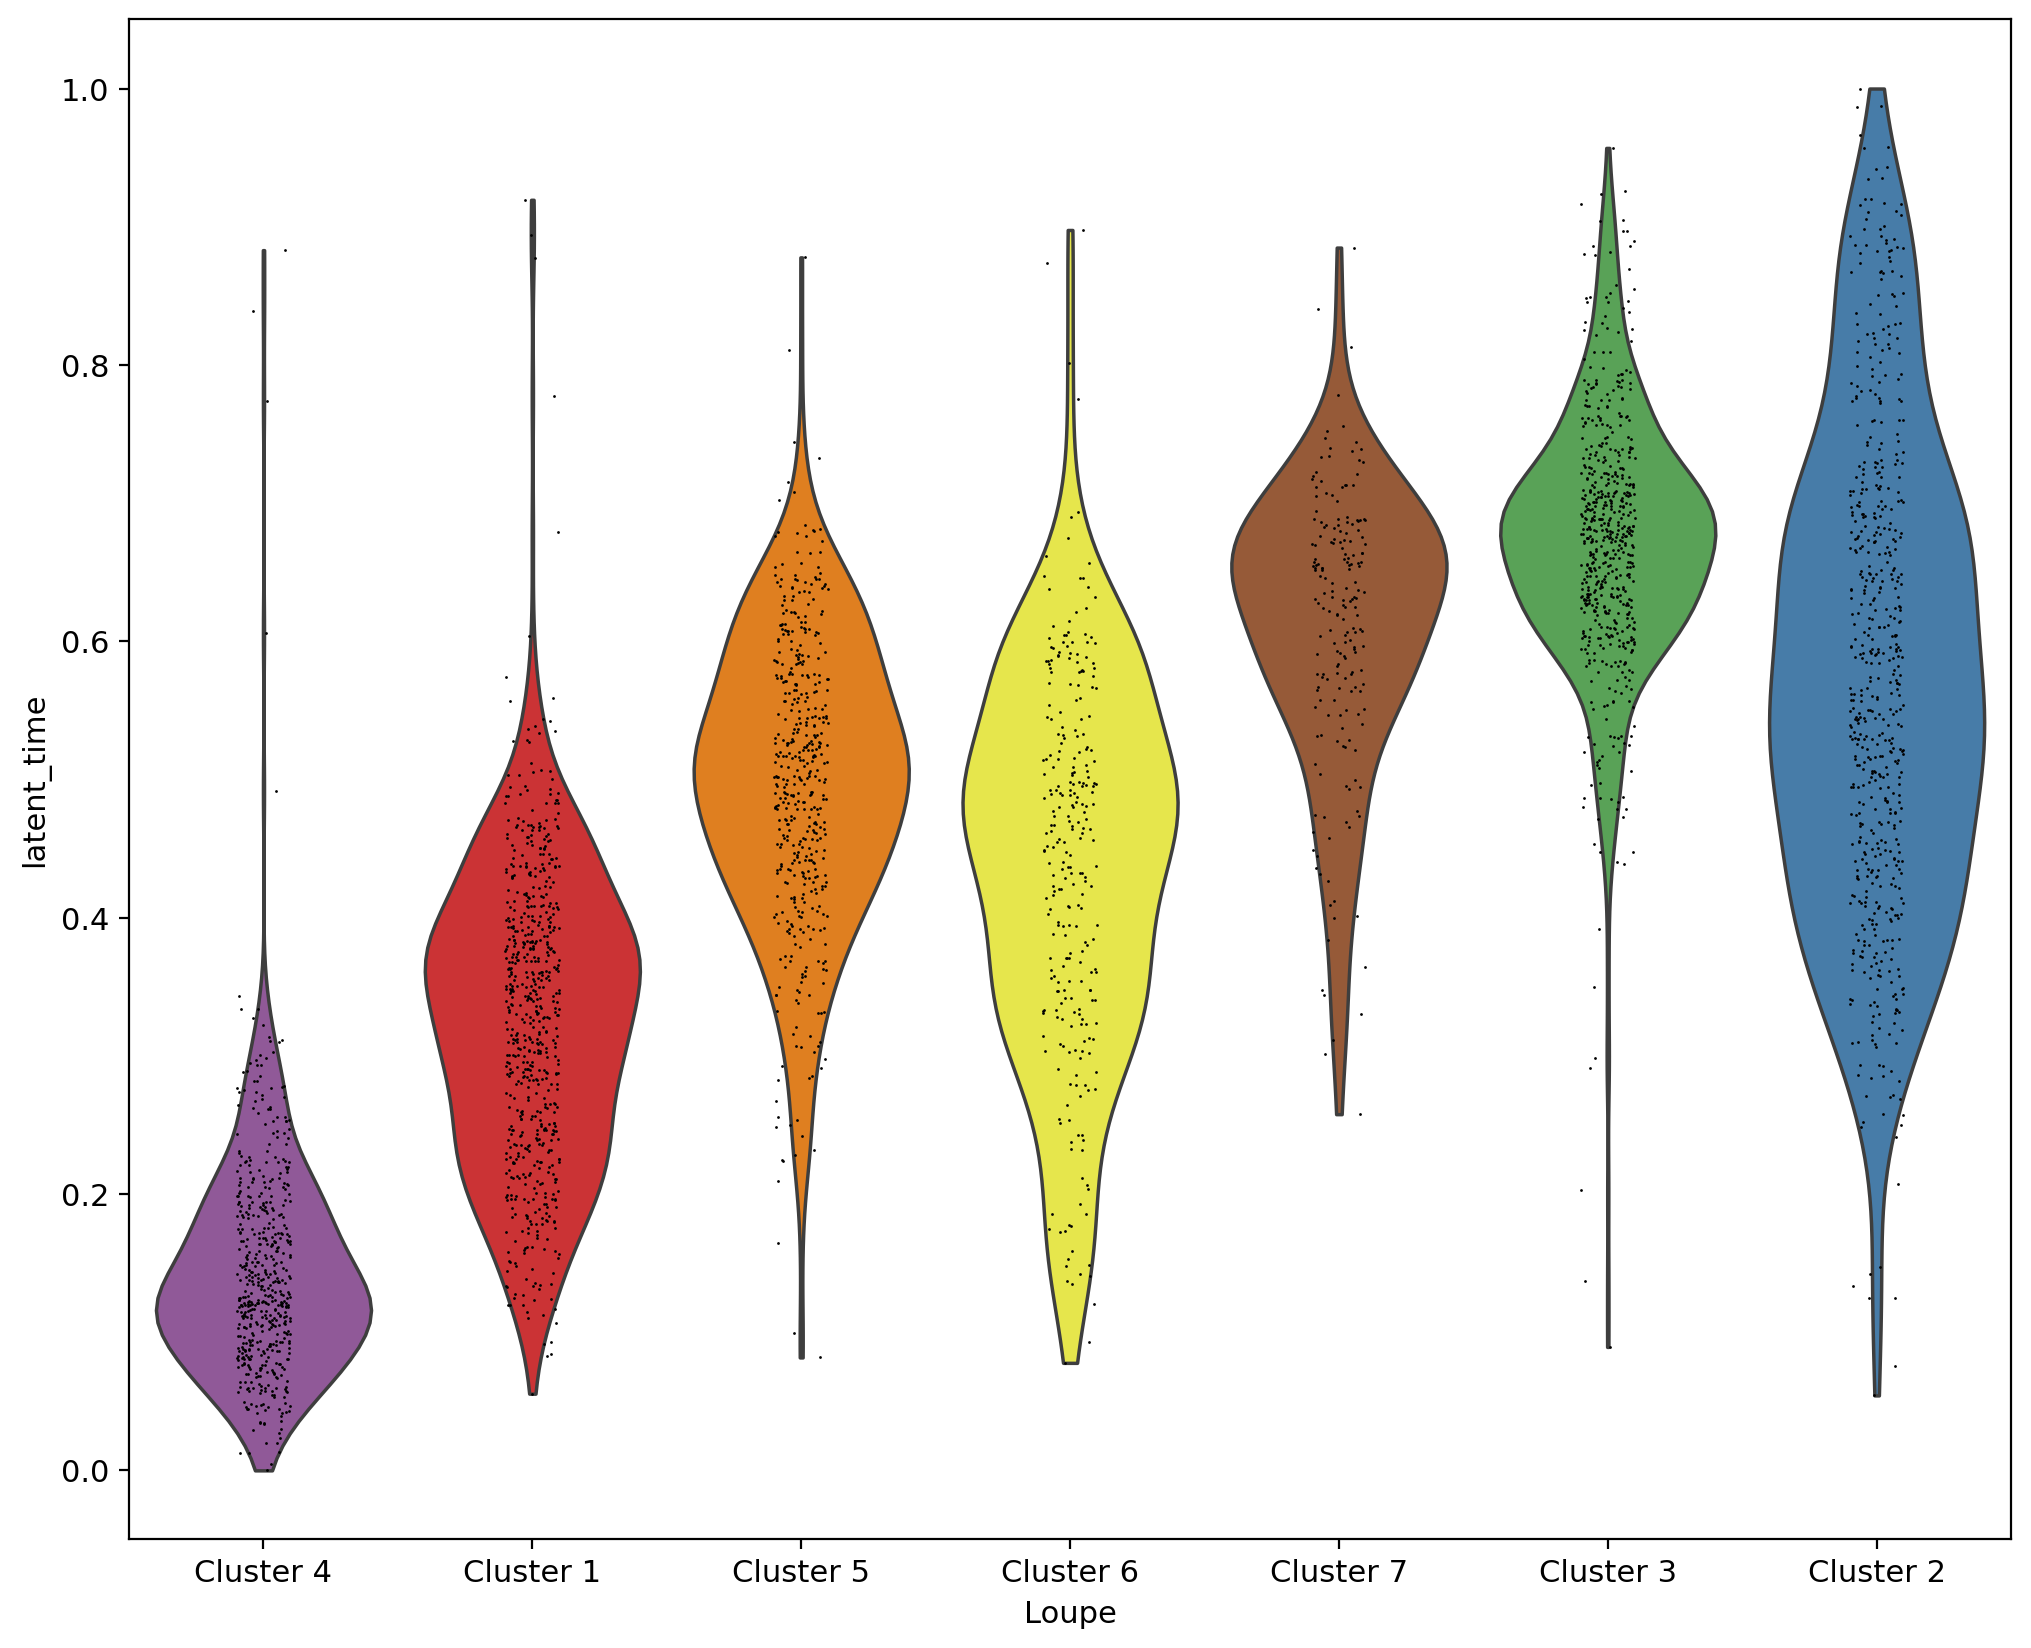

In [54]:
sc.pl.violin(
    Neutro3p, 
    keys='latent_time',
    groupby="Loupe",
    order=["Cluster 4","Cluster 1","Cluster 5","Cluster 6","Cluster 7","Cluster 3","Cluster 2"], 
    save='scVelo-violin-latent_time.png')